# 🐱 Cat Breed Classifier (CatBreedsRefined-7k)
### Transfer Learning with EfficientNetV2S · 20 Refined Cat Breeds

**Dataset**: [CatBreedsRefined-7k — Kaggle](https://www.kaggle.com/datasets/doctrinek/catbreedsrefined-7k)  
**Goal**: Train an accurate image classifier on 20 refined, balanced cat breeds (350 images/class, 7,000 total).  
**Interactive Demo**: Includes an in-notebook upload test cell (Section 9) to test your own cat pictures with instant predictions and breed cards!

**Pipeline Highlights**:
- ⚖️ **Curated & Balanced**: 20 distinct breeds, exactly 350 images per class (7,000 images total)
- 🔥 **EfficientNetV2S Backbone**: High-capacity feature extraction with ImageNet pre-trained weights
- ✅ **Proper Preprocessing**: Scaled through `preprocess_input`
- 🎨 **Data Augmentation**: Flips, rotation, zoom, brightness, contrast, and translations
- 📊 **Complete 20x20 Confusion Matrix**: Full readable evaluation across all 20 classes
- 📤 **In-Notebook Upload Demo**: Upload any cat photo directly in Colab and inspect top-3 confidence scores & breed characteristic cards!

---
> ⚠️ **Before running**: Runtime → Change runtime type → **T4 GPU**

In [4]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
else:
    print("⚠️  No GPU found — go to Runtime > Change runtime type > T4 GPU")

✅ GPU detected: /physical_device:GPU:0


---
## 🔧 Section 1 — Setup & Installation

In [5]:
# Install kaggle API
!pip install kaggle -q
print("✅ kaggle installed")

✅ kaggle installed


In [6]:
# Mount Google Drive (model and metadata will be saved here)
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/cat_breed_classifier_refined7k'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📁 Save directory: {SAVE_DIR}")

Mounted at /content/drive
📁 Save directory: /content/drive/MyDrive/cat_breed_classifier_refined7k


In [7]:
# ─── Paste your Kaggle API token here ─────────────────────────────────
# Go to kaggle.com → Settings → API → Create New Token
# Copy the token string (starts with KGAT_...) and paste below

import os

KAGGLE_TOKEN = 'KGAT_9740d09bffdde6753ab9223292ebc5e2'  # <-- your token

# Save token to the path kaggle CLI reads automatically
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod('/root/.kaggle/access_token', 0o600)

# Quick test — should print dataset info without errors
!kaggle datasets list --max-size 1 -q 2>&1 | head -3
print("✅ Kaggle API token configured!")

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,benchmarks,b,config,auth} ...
kaggle: error: unrecognized arguments: -q
✅ Kaggle API token configured!


In [8]:
# Download and extract the CatBreedsRefined-7k dataset
print("🐱 Downloading CatBreedsRefined-7k dataset (≈464 MB)...")
!kaggle datasets download -d doctrinek/catbreedsrefined-7k --force -q
!unzip -q catbreedsrefined-7k.zip -d /content/catbreedsrefined-7k
print("✅ Dataset ready at /content/catbreedsrefined-7k")
!find /content/catbreedsrefined-7k -maxdepth 3 -type d | head -25

🐱 Downloading CatBreedsRefined-7k dataset (≈464 MB)...
Dataset URL: https://www.kaggle.com/datasets/doctrinek/catbreedsrefined-7k
License(s): CC-BY-SA-4.0
✅ Dataset ready at /content/catbreedsrefined-7k
/content/catbreedsrefined-7k
/content/catbreedsrefined-7k/CatBreedsRefined-v2
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Turkish Angora
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Exotic Shorthair
/content/catbreedsrefined-7k/CatBreedsRefined-v2/American Shorthair
/content/catbreedsrefined-7k/CatBreedsRefined-v2/British Shorthair
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Abyssinian
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Norwegian Forest
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Scottish Fold
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Persian
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Manx
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Sphynx
/content/catbreedsrefined-7k/CatBreedsRefined-v2/Bengal
/content/catbreedsrefined-7k/CatBreedsRefi

In [9]:
# ─── All imports ───────────────────────────────────────────────────────
import os, json, random, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from IPython.display import display, HTML

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU detected: {bool(tf.config.list_physical_devices('GPU'))}")
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow  : 2.20.0
GPU detected: True


---
## 📂 Section 2 — Load & Organise Data

In [10]:
# ─── Scan dataset folders ──────────────────────────────────────────────
DATASET_ROOT = Path('/content/catbreedsrefined-7k')
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

paths, labels = [], []

# Walk every subdirectory — collect images grouped by folder name (= breed)
for folder in sorted(DATASET_ROOT.rglob('*')):
    if folder.is_dir():
        imgs = [p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS]
        if imgs:
            # Normalise breed label: lowercase, spaces/dashes to underscores
            breed = folder.name.lower().strip().replace(' ', '_').replace('-', '_')
            for img in imgs:
                paths.append(str(img))
                labels.append(breed)

df = pd.DataFrame({'path': paths, 'breed': labels})
print(f"✅ Found {len(df):,} images across {df['breed'].nunique()} breed classes")
print("\nClass counts:")
print(df['breed'].value_counts().to_string())

✅ Found 7,000 images across 20 breed classes

Class counts:
breed
abyssinian            350
american_bobtail      350
american_curl         350
american_shorthair    350
bengal                350
birman                350
bombay                350
british_shorthair     350
egyptian_mau          350
exotic_shorthair      350
maine_coon            350
manx                  350
norwegian_forest      350
persian               350
ragdoll               350
russian_blue          350
scottish_fold         350
siamese               350
sphynx                350
turkish_angora        350


In [11]:
# ─── Encode labels & split ─────────────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['breed'])
class_names = list(le.classes_)          # sorted alphabetically
NUM_CLASSES = len(class_names)
print(f"📋 {NUM_CLASSES} classes encoded:")
for i, c in enumerate(class_names):
    print(f"  [{i:2d}] {c}")

# Stratified 80 / 10 / 10 split
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

print(f"\n📊 Split sizes:")
print(f"  Train : {len(train_df):,} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val   : {len(val_df):,} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test  : {len(test_df):,} images ({len(test_df)/len(df)*100:.1f}%)")

📋 20 classes encoded:
  [ 0] abyssinian
  [ 1] american_bobtail
  [ 2] american_curl
  [ 3] american_shorthair
  [ 4] bengal
  [ 5] birman
  [ 6] bombay
  [ 7] british_shorthair
  [ 8] egyptian_mau
  [ 9] exotic_shorthair
  [10] maine_coon
  [11] manx
  [12] norwegian_forest
  [13] persian
  [14] ragdoll
  [15] russian_blue
  [16] scottish_fold
  [17] siamese
  [18] sphynx
  [19] turkish_angora

📊 Split sizes:
  Train : 5,600 images (80.0%)
  Val   : 700 images (10.0%)
  Test  : 700 images (10.0%)


In [12]:
# ─── Save class names to Drive ─────────────────────────────────────────
class_names_path = os.path.join(SAVE_DIR, 'class_names.json')
with open(class_names_path, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=2)
print(f"✅ class_names.json saved → {class_names_path}")

✅ class_names.json saved → /content/drive/MyDrive/cat_breed_classifier_refined7k/class_names.json


---
## 🔍 Section 3 — Explore the Data (EDA)

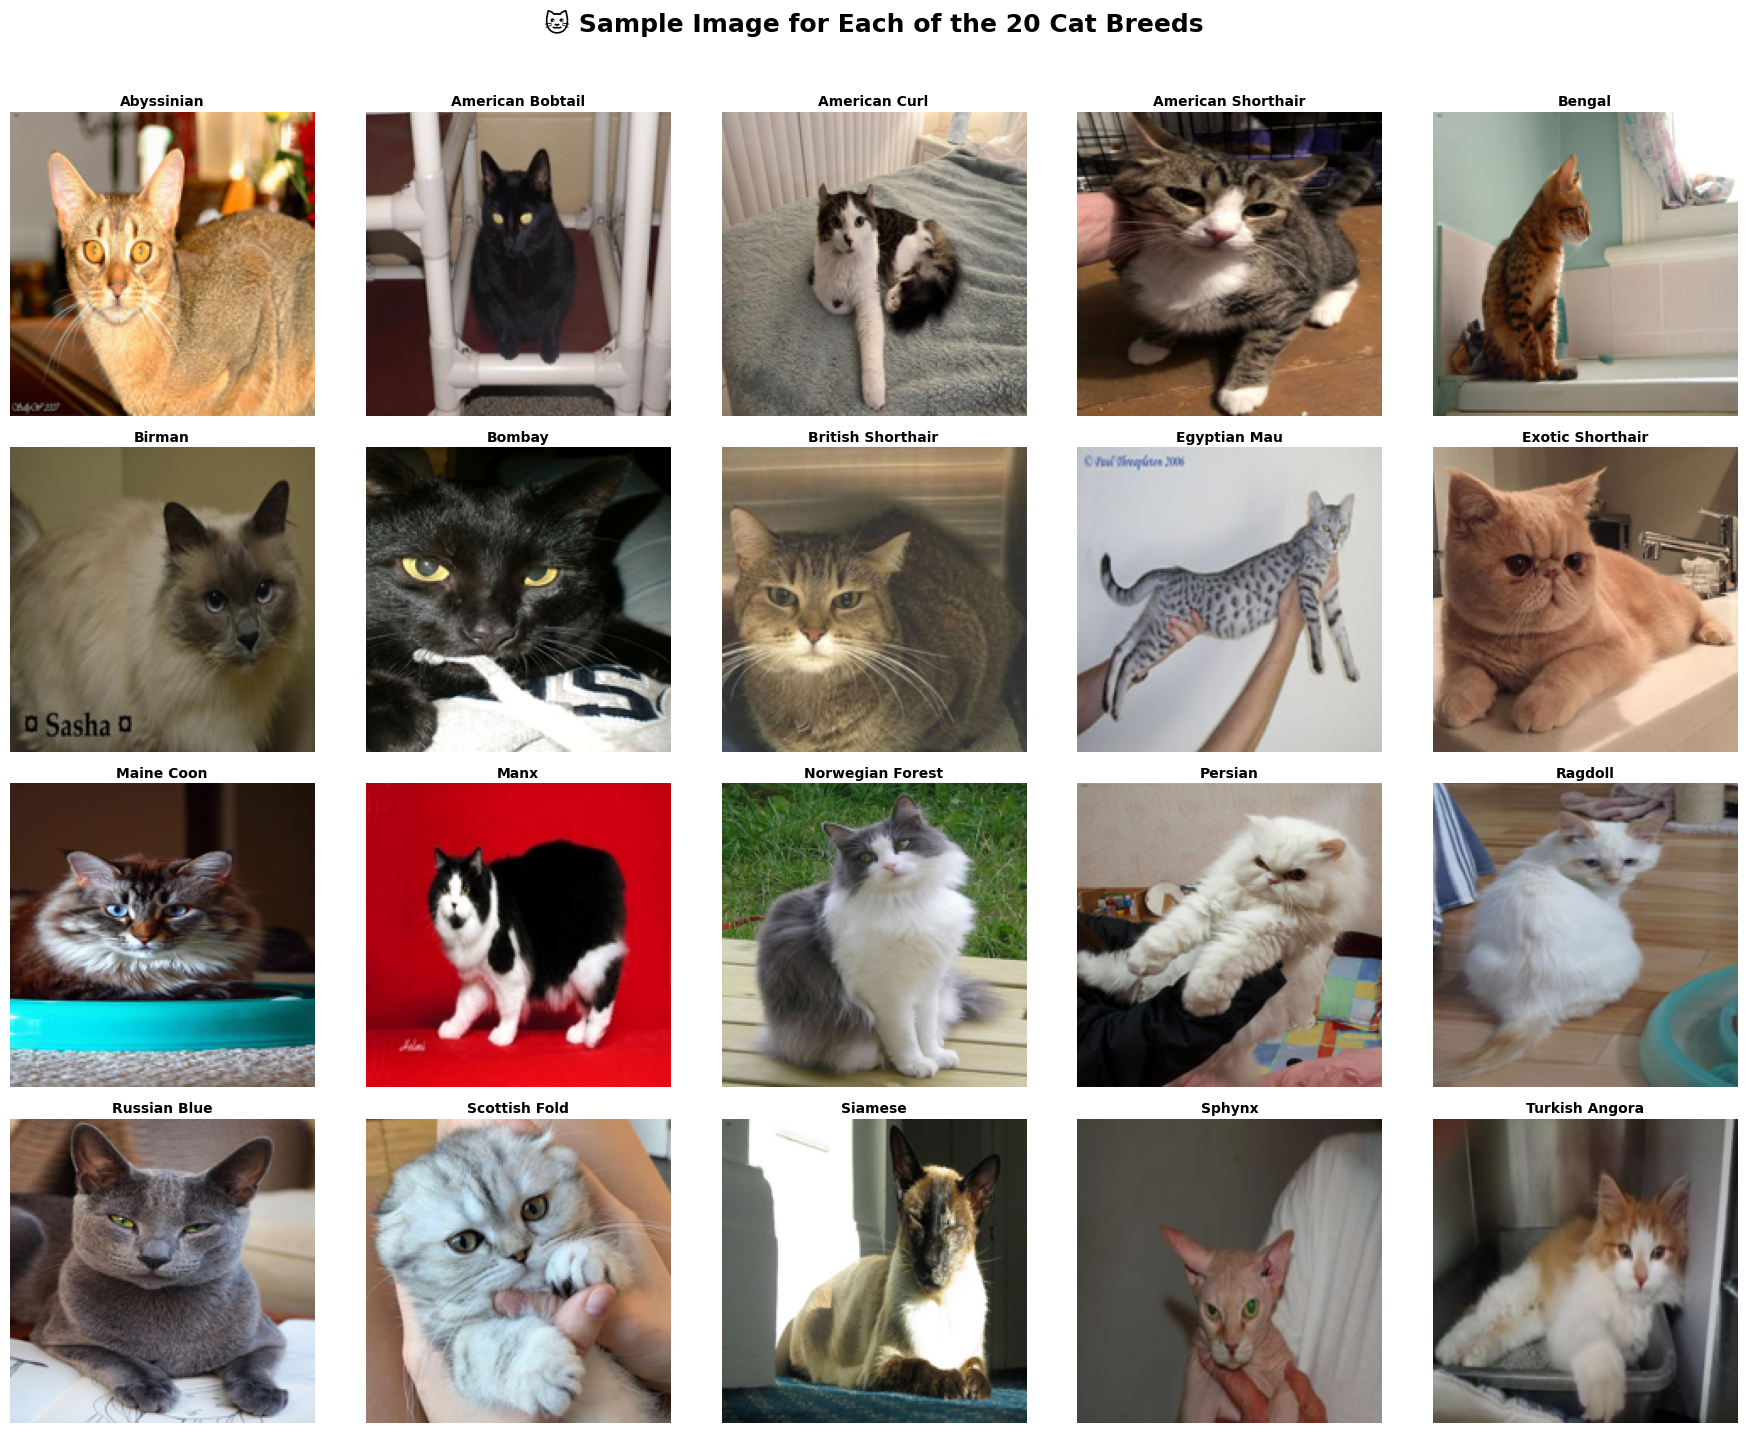

In [13]:
# ─── Sample images grid (All 20 Breeds) ────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('🐱 Sample Image for Each of the 20 Cat Breeds', fontsize=18, fontweight='bold', y=1.02)

for ax, breed in zip(axes.flatten(), class_names):
    breed_rows = df[df['breed'] == breed]
    if len(breed_rows) > 0:
        row = breed_rows.sample(1, random_state=42).iloc[0]
        try:
            img = Image.open(row['path']).convert('RGB').resize((180, 180))
            ax.imshow(img)
        except Exception:
            ax.set_facecolor('#ddd')
    ax.set_title(breed.replace('_', ' ').title(), fontsize=10, pad=4, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sample_breeds.png'), dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_557/671169392.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_557/671169392.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, 'class_distribution.png'), dpi=120, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


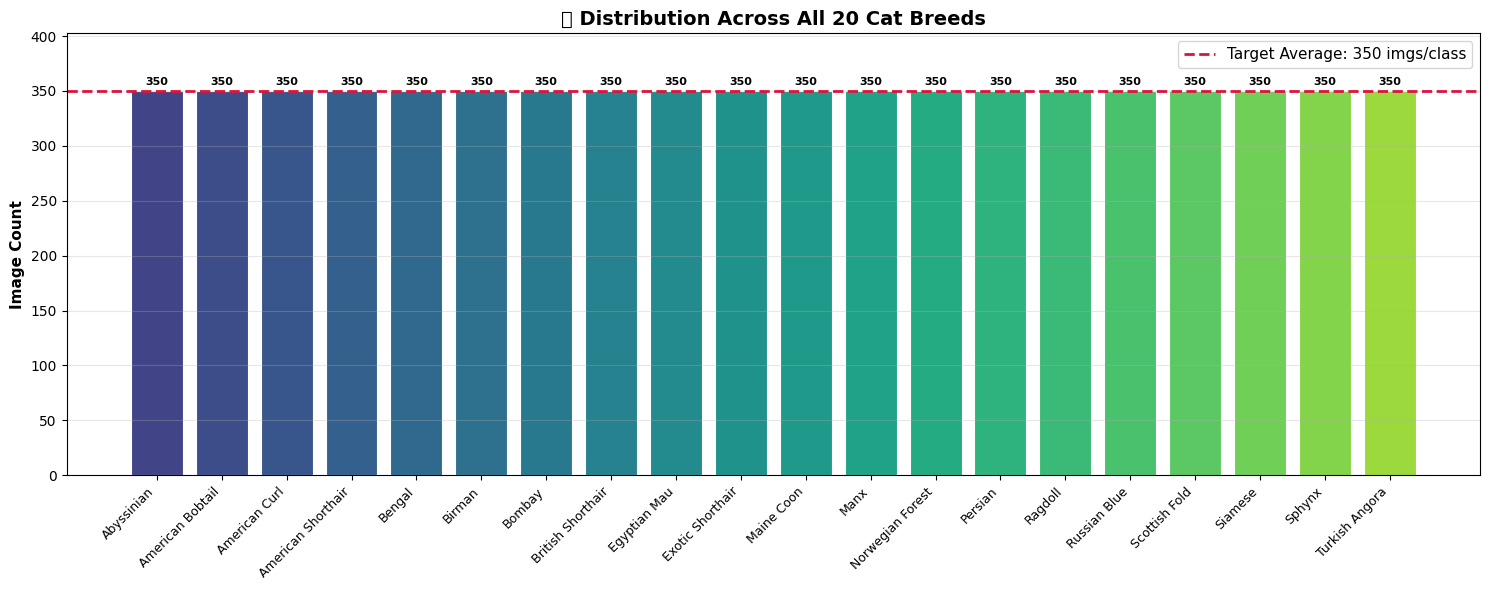

📈 Dataset Statistics:
  Total Images : 7,000
  Total Breeds : 20
  Min Images   : 350 (abyssinian)
  Max Images   : 350 (abyssinian)
  Mean Images  : 350.0


In [14]:
# ─── Class distribution (Uniform Balance Check) ────────────────────────
counts = df['breed'].value_counts()
avg = counts.mean()

fig, ax = plt.subplots(figsize=(15, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(counts)))
bars = ax.bar(range(len(counts)), counts.values, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(avg, color='crimson', linestyle='--', linewidth=2, label=f'Target Average: {avg:.0f} imgs/class')

ax.set_xticks(range(len(counts)))
ax.set_xticklabels([b.replace('_', ' ').title() for b in counts.index], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Image Count', fontsize=11, fontweight='bold')
ax.set_title('📊 Distribution Across All 20 Cat Breeds', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts.values) * 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 4, f'{int(height)}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'class_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f"📈 Dataset Statistics:")
print(f"  Total Images : {counts.sum():,}")
print(f"  Total Breeds : {len(counts)}")
print(f"  Min Images   : {counts.min()} ({counts.idxmin()})")
print(f"  Max Images   : {counts.max()} ({counts.idxmax()})")
print(f"  Mean Images  : {avg:.1f}")

---
## 🧹 Section 4 — Preprocess & Data Augmentation

In [22]:
# ─── Config ────────────────────────────────────────────────────────────
IMG_SIZE   = 224   # EfficientNetV2S default resolution
BATCH_SIZE = 32

# ─── Augmentation pipeline (applied ONLY during training) ──────────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.10, 0.10),
], name='augmentation')

# ─── Image loader ──────────────────────────────────────────────────────
def load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)   # Scales internally for EfficientNetV2
    return img, label

def make_dataset(dataframe, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe['path'].values, dataframe['label'].values)
    )
    if shuffle:
        ds = ds.shuffle(len(dataframe), seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,   augment=False, shuffle=False)
test_ds  = make_dataset(test_df,  augment=False, shuffle=False)

print("✅ tf.data pipelines successfully created")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val batches   : {len(val_ds)}")
print(f"  Test batches  : {len(test_ds)}")

✅ tf.data pipelines successfully created
  Train batches : 175
  Val batches   : 22
  Test batches  : 22


/tmp/ipykernel_557/3093697847.py:25: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


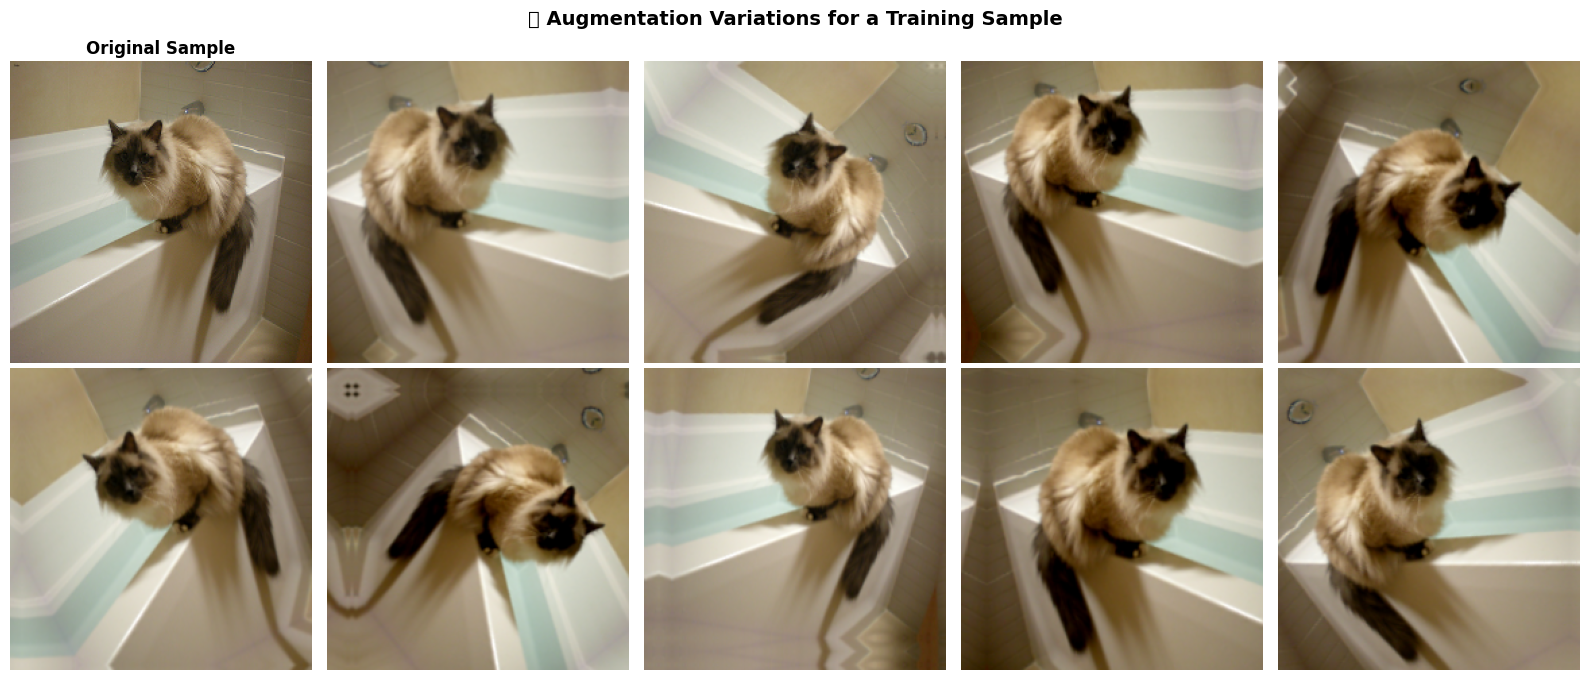

In [23]:
# ─── Visualise augmentation samples ────────────────────────────────────
sample_path = train_df['path'].iloc[0]
raw = tf.io.read_file(sample_path)
img = tf.image.decode_image(raw, channels=3, expand_animations=False)
img = tf.cast(tf.image.resize(img, [IMG_SIZE, IMG_SIZE]), tf.float32)
img = preprocess_input(img)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('🎨 Augmentation Variations for a Training Sample', fontsize=14, fontweight='bold')

def to_display(t):
    t = (t - t.numpy().min()) / (t.numpy().max() - t.numpy().min() + 1e-7)
    return t.numpy()

axes[0, 0].imshow(to_display(img))
axes[0, 0].set_title('Original Sample', fontweight='bold')
axes[0, 0].axis('off')

for ax in list(axes.flatten())[1:]:
    # Pass the image directly since the updated model accepts 3D tensors
    aug = data_augmentation(img, training=True)
    ax.imshow(to_display(aug))
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 🧠 Section 5 — Build the Model (Transfer Learning)

In [26]:
# ─── EfficientNetV2S + Custom Classification Head ─────────────────────
def build_model(num_classes: int, img_size: int = 224):
    base = EfficientNetV2S(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Classification head
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="CatBreedClassifier_Refined7k")
    return model, base

model, base_model = build_model(NUM_CLASSES)
model.summary()

total   = model.count_params()
train_p = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen  = total - train_p
print(f"\n🔢 Parameter Breakdown:")
print(f"   Total params      : {total:,}")
print(f"   Trainable params  : {train_p:,}  (Classification Head)")
print(f"   Frozen params     : {frozen:,}  (Pretrained EfficientNetV2S)")

Model: "CatBreedClassifier_Refined7k"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,126,772 (80.59 MB)

 Trainable params: 793,876 (3.03 MB)

 Non-trainable params: 20,332,896 (77.56 MB)


🔢 Parameter Breakdown:
   Total params      : 21,126,772
   Trainable params  : 793,876  (Classification Head)
   Frozen params     : 20,332,896  (Pretrained EfficientNetV2S)


In [27]:
# ─── Compile Phase 1 ──────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)
print("✅ Model compiled — ready for Phase 1 (Feature Extraction)")

✅ Model compiled — ready for Phase 1 (Feature Extraction)


---
## 🏋️ Section 6 — Two-Phase Training

| Phase | Base Backbone | Epochs | Learning Rate | Expected Val Accuracy |
|---|---|---|---|---|
| **1: Feature Extraction** | Frozen | 15 | `1e-3` | ~80–85% |
| **2: Fine-Tuning** | Top 80 layers unfrozen | 20 | `5e-6` | ~86–92%+ |

In [28]:
# ─── Phase 1 — Feature Extraction (Base Frozen) ───────────────────────
ckpt_p1 = os.path.join(SAVE_DIR, 'best_phase1.h5')

callbacks_p1 = [
    ModelCheckpoint(ckpt_p1, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]

print("🏋️  Starting Phase 1 — training classification head only...")
print("=" * 60)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_p1,
    verbose=1
)

best_p1 = max(history_p1.history['val_accuracy'])
print(f"\n✅ Phase 1 complete! Best val accuracy: {best_p1:.4f} ({best_p1*100:.2f}%)")

🏋️  Starting Phase 1 — training classification head only...
Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.3399 - loss: 2.4273 - top3_acc: 0.5743
Epoch 1: val_accuracy improved from None to 0.63857, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 187s 731ms/step - accuracy: 0.4405 - loss: 1.9551 - top3_acc: 0.6873 - val_accuracy: 0.6386 - val_loss: 1.2072 - val_top3_acc: 0.8586 - learning_rate: 0.0010
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.5437 - loss: 1.4370 - top3_acc: 0.8222
Epoch 2: val_accuracy improved from 0.63857 to 0.67714, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 627ms/step - accuracy: 0.5545 - loss: 1.4084 - top3_acc: 0.8243 - val_accuracy: 0.6771 - val_loss: 0.9982 - val_top3_acc: 0.8900 - learning_rate: 0.0010
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.5932 - loss: 1.2722 - top3_acc: 0.8519
Epoch 3: val_accuracy improved from 0.67714 to 0.68143, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 141s 624ms/step - accuracy: 0.5923 - loss: 1.2786 - top3_acc: 0.8530 - val_accuracy: 0.6814 - val_loss: 0.9077 - val_top3_acc: 0.9000 - learning_rate: 0.0010
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.6121 - loss: 1.2042 - top3_acc: 0.8602
Epoch 4: val_accuracy improved from 0.68143 to 0.72571, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 630ms/step - accuracy: 0.6087 - loss: 1.2010 - top3_acc: 0.8637 - val_accuracy: 0.7257 - val_loss: 0.8863 - val_top3_acc: 0.8986 - learning_rate: 0.0010
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.6378 - loss: 1.1181 - top3_acc: 0.8704
Epoch 5: val_accuracy did not improve from 0.72571
175/175 ━━━━━━━━━━━━━━━━━━━━ 137s 603ms/step - accuracy: 0.6321 - loss: 1.1181 - top3_acc: 0.8739 - val_accuracy: 0.7114 - val_loss: 0.8791 - val_top3_acc: 0.9014 - learning_rate: 0.0010
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.6394 - loss: 1.0814 - top3_acc: 0.8855
Epoch 6: val_accuracy did not improve from 0.72571
175/175 ━━━━━━━━━━━━━━━━━━━━ 106s 603ms/step - accuracy: 0.6411 - loss: 1.1027 - top3_acc: 0.8800 - val_accuracy: 0.7057 - val_loss: 0.9139 - val_top3_acc: 0.9014 - learning_rate: 0.0010
Epoch 7/15
175/175 


Epoch 7: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 109s 621ms/step - accuracy: 0.6577 - loss: 1.0369 - top3_acc: 0.8929 - val_accuracy: 0.7329 - val_loss: 0.8365 - val_top3_acc: 0.9029 - learning_rate: 0.0010
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.6569 - loss: 1.0193 - top3_acc: 0.8870
Epoch 8: val_accuracy did not improve from 0.73286
175/175 ━━━━━━━━━━━━━━━━━━━━ 107s 611ms/step - accuracy: 0.6679 - loss: 1.0172 - top3_acc: 0.8905 - val_accuracy: 0.7171 - val_loss: 0.8380 - val_top3_acc: 0.9286 - learning_rate: 0.0010
Epoch 9/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.6851 - loss: 0.9708 - top3_acc: 0.9088
Epoch 9: val_accuracy did not improve from 0.73286
175/175 ━━━━━━━━━━━━━━━━━━━━ 105s 602ms/step - accuracy: 0.6746 - loss: 0.9925 - top3_acc: 0.9018 - val_accuracy: 0.7071 - val_loss: 0.8770 - val_top3_acc: 0.9029 - learning_rate: 0.0010
Epoch 10/15
175/175


Epoch 11: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 109s 621ms/step - accuracy: 0.7007 - loss: 0.9138 - top3_acc: 0.9079 - val_accuracy: 0.7457 - val_loss: 0.7850 - val_top3_acc: 0.9214 - learning_rate: 5.0000e-04
Epoch 12/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.7168 - loss: 0.8414 - top3_acc: 0.9297
Epoch 12: val_accuracy improved from 0.74571 to 0.76000, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5



Epoch 12: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 111s 629ms/step - accuracy: 0.7048 - loss: 0.8705 - top3_acc: 0.9161 - val_accuracy: 0.7600 - val_loss: 0.7594 - val_top3_acc: 0.9286 - learning_rate: 5.0000e-04
Epoch 13/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.7179 - loss: 0.8518 - top3_acc: 0.9211
Epoch 13: val_accuracy did not improve from 0.76000
175/175 ━━━━━━━━━━━━━━━━━━━━ 110s 628ms/step - accuracy: 0.7146 - loss: 0.8705 - top3_acc: 0.9159 - val_accuracy: 0.7514 - val_loss: 0.7640 - val_top3_acc: 0.9286 - learning_rate: 5.0000e-04
Epoch 14/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.7238 - loss: 0.8370 - top3_acc: 0.9264
Epoch 14: val_accuracy improved from 0.76000 to 0.76286, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5



Epoch 14: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 109s 625ms/step - accuracy: 0.7223 - loss: 0.8427 - top3_acc: 0.9223 - val_accuracy: 0.7629 - val_loss: 0.7342 - val_top3_acc: 0.9214 - learning_rate: 5.0000e-04
Epoch 15/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.7210 - loss: 0.8447 - top3_acc: 0.9264
Epoch 15: val_accuracy improved from 0.76286 to 0.77571, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5



Epoch 15: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_phase1.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 144s 637ms/step - accuracy: 0.7205 - loss: 0.8487 - top3_acc: 0.9255 - val_accuracy: 0.7757 - val_loss: 0.7156 - val_top3_acc: 0.9243 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 15.

✅ Phase 1 complete! Best val accuracy: 0.7757 (77.57%)


In [29]:
# ─── Phase 2 — Fine-Tuning (Top 80 Layers Unfrozen) ───────────────────
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"🔓 Unfrozen {n_trainable} layers in EfficientNetV2S backbone")
print(f"   Trainable params now: {model.count_params():,}")

# Compile with conservative LR for gentle fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)

ckpt_final = os.path.join(SAVE_DIR, 'best_model_final.h5')

callbacks_p2 = [
    ModelCheckpoint(ckpt_final, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-9, verbose=1),
]

print("\n🏋️  Starting Phase 2 — fine-tuning top 80 backbone layers...")
print("=" * 60)

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_p2,
    verbose=1
)

best_p2 = max(history_p2.history['val_accuracy'])
print(f"\n✅ Phase 2 complete! Best val accuracy: {best_p2:.4f} ({best_p2*100:.2f}%)")

🔓 Unfrozen 80 layers in EfficientNetV2S backbone
   Trainable params now: 21,126,772

🏋️  Starting Phase 2 — fine-tuning top 80 backbone layers...
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.6724 - loss: 1.0115 - top3_acc: 0.8870
Epoch 1: val_accuracy improved from None to 0.73857, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 189s 710ms/step - accuracy: 0.6696 - loss: 1.0075 - top3_acc: 0.8930 - val_accuracy: 0.7386 - val_loss: 0.8134 - val_top3_acc: 0.9100 - learning_rate: 5.0000e-06
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.6788 - loss: 0.9654 - top3_acc: 0.9002
Epoch 2: val_accuracy did not improve from 0.73857
175/175 ━━━━━━━━━━━━━━━━━━━━ 112s 638ms/step - accuracy: 0.6821 - loss: 0.9579 - top3_acc: 0.9036 - val_accuracy: 0.7314 - val_loss: 0.8157 - val_top3_acc: 0.9157 - learning_rate: 5.0000e-06
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.6821 - loss: 0.9578 - top3_acc: 0.9058
Epoch 3: val_accuracy improved from 0.73857 to 0.74143, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 143s 645ms/step - accuracy: 0.6843 - loss: 0.9558 - top3_acc: 0.9021 - val_accuracy: 0.7414 - val_loss: 0.7917 - val_top3_acc: 0.9129 - learning_rate: 5.0000e-06
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.6972 - loss: 0.9353 - top3_acc: 0.9050
Epoch 4: val_accuracy improved from 0.74143 to 0.75429, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 117s 664ms/step - accuracy: 0.6945 - loss: 0.9405 - top3_acc: 0.9025 - val_accuracy: 0.7543 - val_loss: 0.7785 - val_top3_acc: 0.9171 - learning_rate: 5.0000e-06
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.7142 - loss: 0.9004 - top3_acc: 0.9129
Epoch 5: val_accuracy improved from 0.75429 to 0.75571, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5



Epoch 5: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 141s 664ms/step - accuracy: 0.7086 - loss: 0.9082 - top3_acc: 0.9093 - val_accuracy: 0.7557 - val_loss: 0.7643 - val_top3_acc: 0.9143 - learning_rate: 5.0000e-06
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.7174 - loss: 0.8437 - top3_acc: 0.9182
Epoch 6: val_accuracy improved from 0.75571 to 0.76714, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5



Epoch 6: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 118s 673ms/step - accuracy: 0.7111 - loss: 0.8748 - top3_acc: 0.9127 - val_accuracy: 0.7671 - val_loss: 0.7522 - val_top3_acc: 0.9157 - learning_rate: 5.0000e-06
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.7158 - loss: 0.8799 - top3_acc: 0.9161
Epoch 7: val_accuracy did not improve from 0.76714
175/175 ━━━━━━━━━━━━━━━━━━━━ 135s 636ms/step - accuracy: 0.7161 - loss: 0.8834 - top3_acc: 0.9150 - val_accuracy: 0.7671 - val_loss: 0.7373 - val_top3_acc: 0.9271 - learning_rate: 5.0000e-06
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.7156 - loss: 0.8484 - top3_acc: 0.9209
Epoch 8: val_accuracy did not improve from 0.76714
175/175 ━━━━━━━━━━━━━━━━━━━━ 108s 618ms/step - accuracy: 0.7195 - loss: 0.8535 - top3_acc: 0.9186 - val_accuracy: 0.7671 - val_loss: 0.7401 - val_top3_acc: 0.9229 - learning_rate: 5.0000e-06
Ep


Epoch 9: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 150s 664ms/step - accuracy: 0.7279 - loss: 0.8409 - top3_acc: 0.9218 - val_accuracy: 0.7729 - val_loss: 0.7275 - val_top3_acc: 0.9243 - learning_rate: 5.0000e-06
Epoch 10/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.7237 - loss: 0.8214 - top3_acc: 0.9245
Epoch 10: val_accuracy did not improve from 0.77286
175/175 ━━━━━━━━━━━━━━━━━━━━ 136s 628ms/step - accuracy: 0.7237 - loss: 0.8221 - top3_acc: 0.9243 - val_accuracy: 0.7657 - val_loss: 0.7244 - val_top3_acc: 0.9286 - learning_rate: 5.0000e-06
Epoch 11/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.7243 - loss: 0.8520 - top3_acc: 0.9171
Epoch 11: val_accuracy did not improve from 0.77286
175/175 ━━━━━━━━━━━━━━━━━━━━ 141s 620ms/step - accuracy: 0.7234 - loss: 0.8518 - top3_acc: 0.9204 - val_accuracy: 0.7729 - val_loss: 0.7083 - val_top3_acc: 0.9314 - learning_rate: 5.0000e-0


Epoch 13: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 113s 641ms/step - accuracy: 0.7373 - loss: 0.8003 - top3_acc: 0.9270 - val_accuracy: 0.7886 - val_loss: 0.7060 - val_top3_acc: 0.9343 - learning_rate: 5.0000e-06
Epoch 14/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.7315 - loss: 0.7880 - top3_acc: 0.9336
Epoch 14: val_accuracy did not improve from 0.78857
175/175 ━━━━━━━━━━━━━━━━━━━━ 112s 636ms/step - accuracy: 0.7312 - loss: 0.8074 - top3_acc: 0.9289 - val_accuracy: 0.7757 - val_loss: 0.7031 - val_top3_acc: 0.9357 - learning_rate: 5.0000e-06
Epoch 15/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.7396 - loss: 0.7867 - top3_acc: 0.9242
Epoch 15: val_accuracy did not improve from 0.78857
175/175 ━━━━━━━━━━━━━━━━━━━━ 109s 622ms/step - accuracy: 0.7359 - loss: 0.7862 - top3_acc: 0.9298 - val_accuracy: 0.7843 - val_loss: 0.6865 - val_top3_acc: 0.9386 - learning_rate: 5.0000e-


Epoch 18: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 119s 681ms/step - accuracy: 0.7491 - loss: 0.7587 - top3_acc: 0.9361 - val_accuracy: 0.7929 - val_loss: 0.6760 - val_top3_acc: 0.9443 - learning_rate: 5.0000e-06
Epoch 19/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.7554 - loss: 0.7376 - top3_acc: 0.9385
Epoch 19: val_accuracy did not improve from 0.79286
175/175 ━━━━━━━━━━━━━━━━━━━━ 132s 622ms/step - accuracy: 0.7502 - loss: 0.7539 - top3_acc: 0.9348 - val_accuracy: 0.7914 - val_loss: 0.6797 - val_top3_acc: 0.9371 - learning_rate: 5.0000e-06
Epoch 20/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.7351 - loss: 0.7690 - top3_acc: 0.9325
Epoch 20: val_accuracy improved from 0.79286 to 0.79429, saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5



Epoch 20: finished saving model to /content/drive/MyDrive/cat_breed_classifier_refined7k/best_model_final.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 147s 654ms/step - accuracy: 0.7443 - loss: 0.7637 - top3_acc: 0.9312 - val_accuracy: 0.7943 - val_loss: 0.6688 - val_top3_acc: 0.9400 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 20.

✅ Phase 2 complete! Best val accuracy: 0.7943 (79.43%)


---
## 📊 Section 7 — Comprehensive Evaluation

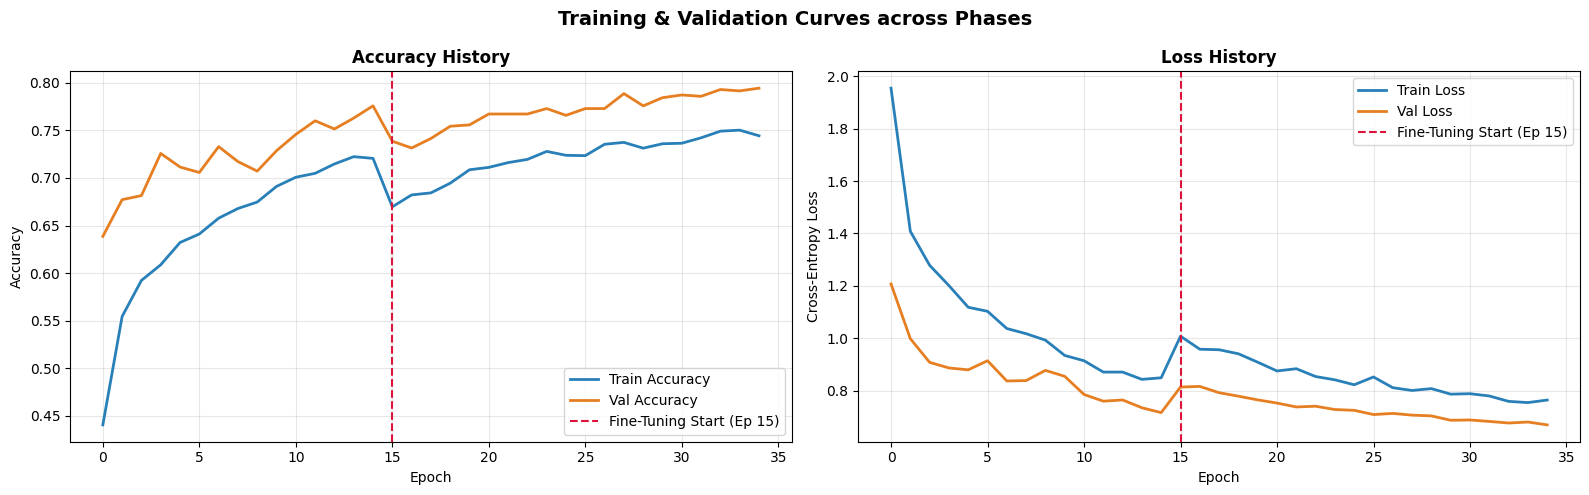

In [30]:
# ─── Training History Curves ──────────────────────────────────────────
def plot_history(h1, h2):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    split    = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Training & Validation Curves across Phases', fontsize=14, fontweight='bold')

    # Accuracy plot
    ax1.plot(acc, label='Train Accuracy', color='#2980b9', linewidth=2)
    ax1.plot(val_acc, label='Val Accuracy', color='#e67e22', linewidth=2)
    ax1.axvline(split, color='crimson', linestyle='--', linewidth=1.5, label=f'Fine-Tuning Start (Ep {split})')
    ax1.set_title('Accuracy History', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss plot
    ax2.plot(loss, label='Train Loss', color='#2980b9', linewidth=2)
    ax2.plot(val_loss, label='Val Loss', color='#e67e22', linewidth=2)
    ax2.axvline(split, color='crimson', linestyle='--', linewidth=1.5, label=f'Fine-Tuning Start (Ep {split})')
    ax2.set_title('Loss History', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Cross-Entropy Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'training_history.png'), dpi=120, bbox_inches='tight')
    plt.show()

plot_history(history_p1, history_p2)

In [ ]:
# ─── Test Set Evaluation ───────────────────────────────────────────────
print("📊 Evaluating on unseen TEST set (700 images)...")
test_loss, test_acc, test_top3 = model.evaluate(test_ds, verbose=0)

print(f"\n{'='*45}")
print(f"  Top-1 Accuracy : {test_acc*100:.2f}%")
print(f"  Top-3 Accuracy : {test_top3*100:.2f}%")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"{'='*45}")

In [31]:
# ─── Per-Breed Classification Report ───────────────────────────────────
print("📋 Computing classification report across all 20 breeds...")

y_true, y_pred = [], []
for images, labels_batch in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true_names = [class_names[i] for i in y_true]
y_pred_names = [class_names[i] for i in y_pred]

print(classification_report(y_true_names, y_pred_names, zero_division=0))

📋 Computing classification report across all 20 breeds...
                    precision    recall  f1-score   support

        abyssinian       0.86      0.69      0.76        35
  american_bobtail       0.67      0.46      0.54        35
     american_curl       0.77      0.77      0.77        35
american_shorthair       0.58      0.54      0.56        35
            bengal       0.71      0.77      0.74        35
            birman       0.74      0.83      0.78        35
            bombay       0.85      1.00      0.92        35
 british_shorthair       0.70      0.66      0.68        35
      egyptian_mau       0.68      0.60      0.64        35
  exotic_shorthair       0.85      0.97      0.91        35
        maine_coon       0.60      0.51      0.55        35
              manx       0.70      0.86      0.77        35
  norwegian_forest       0.65      0.80      0.72        35
           persian       0.87      0.97      0.92        35
           ragdoll       0.80      0.69  

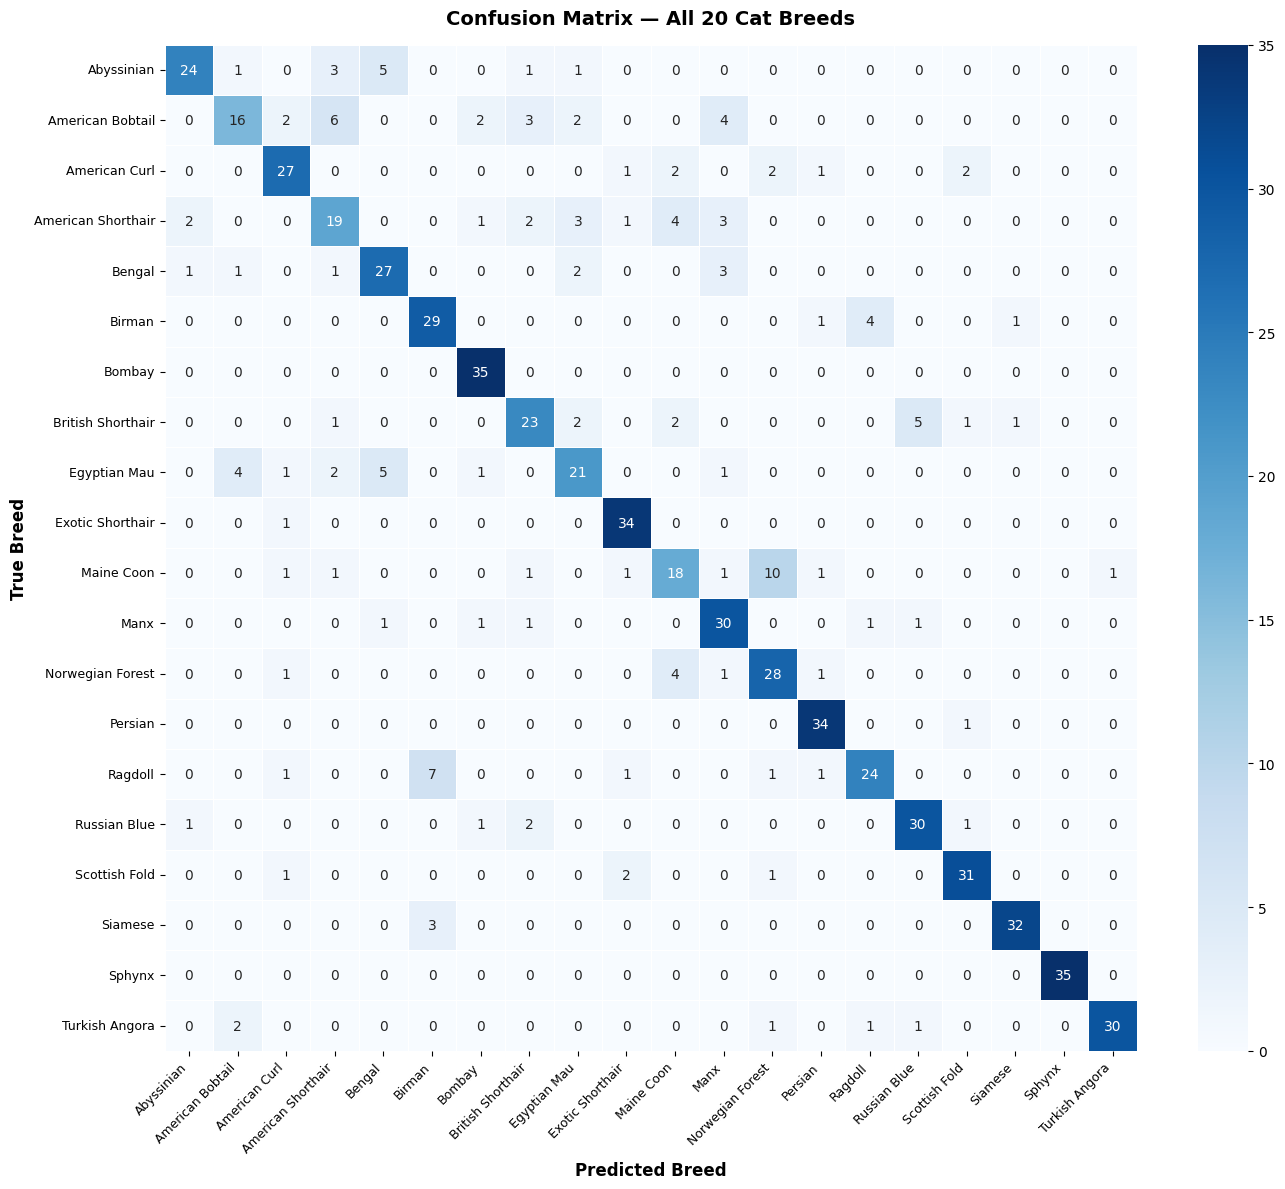

In [32]:
# ─── Full 20x20 Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
labels_display = [b.replace('_', ' ').title() for b in class_names]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_display, yticklabels=labels_display,
    linewidths=0.5, linecolor='white', cbar=True
)
plt.title('Confusion Matrix — All 20 Cat Breeds', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Breed', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Breed', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## 💾 Section 8 — Save Model & Breed Characteristics

In [33]:
# ─── Comprehensive Breed Information Dictionary ────────────────────────
BREED_INFO = {
    "abyssinian":          {"origin": "Ethiopia", "lifespan": "9–15 yrs", "temperament": "Active, Curious, Playful, Intelligent", "fun_fact": "Often depicted in ancient Egyptian art — one of the oldest known breeds."},
    "american_bobtail":    {"origin": "United States", "lifespan": "11–15 yrs", "temperament": "Friendly, Intelligent, Adaptable", "fun_fact": "They love to play fetch — very dog-like personality!"},
    "american_curl":       {"origin": "United States", "lifespan": "12–16 yrs", "temperament": "Affectionate, Social, Gentle", "fun_fact": "Born with straight ears that curl backward within days of birth."},
    "american_shorthair":  {"origin": "United States", "lifespan": "15–20 yrs", "temperament": "Easygoing, Adaptable, Gentle", "fun_fact": "One of the most popular cat breeds in the USA, descended from working cats."},
    "american_wirehair":   {"origin": "United States", "lifespan": "14–18 yrs", "temperament": "Adaptable, Affectionate, Playful", "fun_fact": "Their unique wiry coat is a natural mutation first seen in 1966."},
    "balinese":            {"origin": "United States", "lifespan": "12–20 yrs", "temperament": "Vocal, Intelligent, Affectionate", "fun_fact": "Sometimes called the 'long-haired Siamese' — same vocal personality!"},
    "bengal":              {"origin": "United States", "lifespan": "12–16 yrs", "temperament": "Active, Energetic, Curious, Playful", "fun_fact": "Descended from Asian Leopard Cats — wild look, domestic heart."},
    "birman":              {"origin": "Burma (Myanmar)", "lifespan": "12–16 yrs", "temperament": "Gentle, Affectionate, Social", "fun_fact": "Legend says Birmans were sacred temple cats blessed by a golden goddess."},
    "bombay":              {"origin": "United States", "lifespan": "12–18 yrs", "temperament": "Affectionate, Playful, Social", "fun_fact": "Bred to look like a miniature black panther — nicknamed 'parlor panther'."},
    "british_shorthair":   {"origin": "United Kingdom", "lifespan": "12–20 yrs", "temperament": "Calm, Easygoing, Affectionate", "fun_fact": "The Cheshire Cat from Alice in Wonderland was inspired by this breed!"},
    "burmese":             {"origin": "Burma (Myanmar)", "lifespan": "16–18 yrs", "temperament": "Social, Affectionate, Energetic", "fun_fact": "All Burmese worldwide trace back to a single female cat brought to the USA in 1930."},
    "chartreux":           {"origin": "France", "lifespan": "11–15 yrs", "temperament": "Quiet, Gentle, Loyal, Playful", "fun_fact": "French monks at the Grande Chartreuse monastery are said to have bred this cat."},
    "chausie":             {"origin": "United States", "lifespan": "12–14 yrs", "temperament": "Active, Loyal, Intelligent", "fun_fact": "Descended from the Jungle Cat (Felis chaus) — one of the closest to wild cats."},
    "cornish_rex":         {"origin": "Cornwall, UK", "lifespan": "11–15 yrs", "temperament": "Active, Playful, Sociable, Mischievous", "fun_fact": "Has only the soft undercoat — no guard hairs, giving a uniquely curly look."},
    "cymric":              {"origin": "Canada / Isle of Man", "lifespan": "8–14 yrs", "temperament": "Gentle, Playful, Intelligent", "fun_fact": "Essentially a long-haired Manx — they share the taillessness gene."},
    "cyprus":              {"origin": "Cyprus", "lifespan": "12–15 yrs", "temperament": "Adaptable, Friendly, Independent", "fun_fact": "One of the oldest domesticated cat breeds — evidence dates back 9,500 years!"},
    "devon_rex":           {"origin": "Devon, UK", "lifespan": "9–15 yrs", "temperament": "Mischievous, Playful, People-oriented", "fun_fact": "Called 'pixie cats' due to their large ears and elfin face."},
    "donskoy":             {"origin": "Russia", "lifespan": "12–15 yrs", "temperament": "Affectionate, Loyal, Curious", "fun_fact": "Hairlessness is caused by a dominant gene — unlike Sphynx which is recessive."},
    "egyptian_mau":        {"origin": "Egypt", "lifespan": "12–15 yrs", "temperament": "Active, Loyal, Playful", "fun_fact": "The only naturally spotted domestic cat breed — spots are in the coat, not just the skin!"},
    "european_shorthair":  {"origin": "Europe", "lifespan": "15–20 yrs", "temperament": "Adaptable, Playful, Independent", "fun_fact": "The most common cat in Europe, descended from cats the Romans spread across the continent."},
    "exotic_shorthair":    {"origin": "United States", "lifespan": "12–15 yrs", "temperament": "Calm, Gentle, Playful, Affectionate", "fun_fact": "Nicknamed 'the lazy man's Persian' — same look, easier-to-maintain coat."},
    "german_rex":          {"origin": "Germany", "lifespan": "12–15 yrs", "temperament": "Affectionate, Playful, Curious, Social", "fun_fact": "One of the first curly-coated breeds, discovered in Germany after World War II."},
    "havana_brown":        {"origin": "United Kingdom", "lifespan": "10–15 yrs", "temperament": "Affectionate, Curious, Playful, Social", "fun_fact": "The only all-brown cat breed — their rich mahogany color inspired the name 'Havana'."},
    "himalayan":           {"origin": "United States", "lifespan": "9–15 yrs", "temperament": "Calm, Gentle, Sweet, Quiet", "fun_fact": "A Persian × Siamese cross — Persian body with Siamese color points."},
    "japanese_bobtail":    {"origin": "Japan", "lifespan": "15–18 yrs", "temperament": "Active, Vocal, Sociable, Friendly", "fun_fact": "The 'Maneki-neko' lucky waving cat figurine is modeled after this breed!"},
    "karelian_bobtail":    {"origin": "Russia / Finland", "lifespan": "12–15 yrs", "temperament": "Calm, Friendly, Adaptable", "fun_fact": "A rare natural breed from Karelian forests with a pom-pom tail."},
    "khao_manee":          {"origin": "Thailand", "lifespan": "10–12 yrs", "temperament": "Curious, Playful, Affectionate, Social", "fun_fact": "An ancient Thai royal cat — once exclusive to royalty."},
    "korat":               {"origin": "Thailand", "lifespan": "15+ yrs", "temperament": "Gentle, Loyal, Playful, Affectionate", "fun_fact": "In Thailand, Korats are considered good luck and gifted to newlyweds."},
    "korean_bobtail":      {"origin": "Korea", "lifespan": "10–14 yrs", "temperament": "Active, Curious, Friendly, Independent", "fun_fact": "A natural breed from Korea with a distinctive short, pom-pom tail."},
    "kurilian_bobtail":    {"origin": "Russia (Kuril Islands)", "lifespan": "15–20 yrs", "temperament": "Gentle, Social, Playful, Adaptable", "fun_fact": "Natural hunters from the remote Kuril Islands — excellent fishers!"},
    "laperm":              {"origin": "United States", "lifespan": "10–15 yrs", "temperament": "Affectionate, Gentle, Curious, Active", "fun_fact": "Born bald, they grow a unique curly coat — each cat's curls are different!"},
    "lykoi":               {"origin": "United States", "lifespan": "12–15 yrs", "temperament": "Loyal, Playful, Friendly, Curious", "fun_fact": "Called the 'Werewolf Cat' — their patchy coat gives a spooky, Halloween appearance."},
    "maine_coon":          {"origin": "United States (Maine)", "lifespan": "12–15 yrs", "temperament": "Friendly, Playful, Gentle, Dog-like", "fun_fact": "The largest domestic cat breed — males can reach 18 lbs! They love water."},
    "manx":                {"origin": "Isle of Man", "lifespan": "14–16 yrs", "temperament": "Gentle, Playful, Social, Loyal", "fun_fact": "Naturally tailless due to a genetic mutation — can be fully tailless or have a stub."},
    "mekong_bobtail":      {"origin": "Southeast Asia", "lifespan": "12–15 yrs", "temperament": "Affectionate, Loyal, Social, Gentle", "fun_fact": "Named after the Mekong River — historically kept by royalty across Southeast Asia."},
    "munchkin":            {"origin": "United States", "lifespan": "12–15 yrs", "temperament": "Playful, Outgoing, Affectionate, Curious", "fun_fact": "Their short legs are a natural mutation — they can still run surprisingly fast!"},
    "nebelung":            {"origin": "United States", "lifespan": "15–18 yrs", "temperament": "Gentle, Shy, Loyal, Affectionate", "fun_fact": "Named after German mythology ('creature of the mist') — their shimmery coat inspired it."},
    "norwegian_forest_cat":{"origin": "Norway", "lifespan": "12–16 yrs", "temperament": "Independent, Gentle, Adventurous", "fun_fact": "Vikings likely kept these cats on ships to catch mice during long voyages!"},
    "ocicat":              {"origin": "United States", "lifespan": "12–18 yrs", "temperament": "Active, Sociable, Curious, Playful", "fun_fact": "Looks wild but is entirely domestic — created by accident from Siamese × Abyssinian crosses."},
    "oregon_rex":          {"origin": "United States (Oregon)", "lifespan": "12–15 yrs", "temperament": "Playful, Affectionate, Gentle, Social", "fun_fact": "An extremely rare curly-coated breed — now considered an extinct separate variety."},
    "oriental_shorthair":  {"origin": "United Kingdom", "lifespan": "12–15 yrs", "temperament": "Vocal, Sociable, Affectionate, Demanding", "fun_fact": "Comes in over 300 color and pattern combinations — more than any other breed!"},
    "persian":             {"origin": "Iran (Persia)", "lifespan": "12–17 yrs", "temperament": "Gentle, Quiet, Calm, Affectionate", "fun_fact": "Their luxurious coat can grow up to 6 inches long and needs daily brushing."},
    "peterbald":           {"origin": "Russia (St. Petersburg)", "lifespan": "12–15 yrs", "temperament": "Affectionate, Curious, Energetic, Social", "fun_fact": "Created in 1994 by crossing a Donskoy with an Oriental Shorthair."},
    "pixie_bob":           {"origin": "United States", "lifespan": "13–15 yrs", "temperament": "Sociable, Loyal, Gentle, Dog-like", "fun_fact": "Rumored to descend from bobcats — DNA tests show they are fully domestic."},
    "ragamuffin":          {"origin": "United States", "lifespan": "12–16 yrs", "temperament": "Gentle, Calm, Affectionate, Patient", "fun_fact": "They go completely limp when held — nicknamed 'puppy cats'."},
    "ragdoll":             {"origin": "United States", "lifespan": "12–17 yrs", "temperament": "Gentle, Relaxed, Affectionate, Calm", "fun_fact": "Named 'Ragdoll' because they go limp and floppy when you pick them up!"},
    "russian_blue":        {"origin": "Russia", "lifespan": "15–20 yrs", "temperament": "Gentle, Reserved, Loyal, Intelligent", "fun_fact": "Their double coat has silver-tipped guard hairs giving a shimmering blue glow."},
    "safari":              {"origin": "United States", "lifespan": "12–16 yrs", "temperament": "Active, Curious, Affectionate, Energetic", "fun_fact": "A rare hybrid from domestic cats × wild Geoffroy's Cat from South America."},
    "savannah":            {"origin": "United States", "lifespan": "12–20 yrs", "temperament": "Active, Adventurous, Loyal, Curious", "fun_fact": "The tallest domestic cat — crossed with Serval, they can jump over 8 feet high!"},
    "scottish_fold":       {"origin": "Scotland", "lifespan": "11–14 yrs", "temperament": "Adaptable, Sweet, Calm, Gentle", "fun_fact": "All Scottish Folds trace back to one barn cat named Susie, found in Scotland in 1961."},
    "selkirk_rex":         {"origin": "United States", "lifespan": "14–15 yrs", "temperament": "Tolerant, Loving, Playful, Patient", "fun_fact": "Named after the Selkirk Mountains — the only curly-coated breed named after a person!"},
    "serengeti":           {"origin": "United States", "lifespan": "10–15 yrs", "temperament": "Active, Vocal, Sociable, Energetic", "fun_fact": "Bred to look like a Serval — from Bengal × Oriental Shorthair crosses, no wild blood."},
    "siamese":             {"origin": "Thailand", "lifespan": "12–20 yrs", "temperament": "Vocal, Social, Intelligent, Affectionate", "fun_fact": "One of the oldest recognized Asian cat breeds, famous for striking blue almond eyes."},
    "siberian":            {"origin": "Russia", "lifespan": "11–18 yrs", "temperament": "Playful, Affectionate, Adventurous, Loyal", "fun_fact": "Russia's national cat — centuries-old forest breed, and semi-hypoallergenic!"},
    "singapura":           {"origin": "Singapore", "lifespan": "11–15 yrs", "temperament": "Curious, Playful, Affectionate, Sociable", "fun_fact": "The smallest domestic cat breed — adults weigh only 4–8 pounds!"},
    "sokoke":              {"origin": "Kenya", "lifespan": "9–15 yrs", "temperament": "Active, Sociable, Intelligent, Dog-like", "fun_fact": "One of the rarest breeds — discovered living wild in Kenya's Arabuko-Sokoke Forest."},
    "somali":              {"origin": "United States / Canada", "lifespan": "12–16 yrs", "temperament": "Active, Curious, Playful, Sociable", "fun_fact": "Called the 'fox cat' — essentially a long-haired Abyssinian with a fluffy tail."},
    "sphynx":              {"origin": "Canada", "lifespan": "8–14 yrs", "temperament": "Energetic, Mischievous, Warm, Social", "fun_fact": "Despite looking hairless, they're covered in fine peach-fuzz and feel like warm suede!"},
    "thai":                {"origin": "Thailand", "lifespan": "12–16 yrs", "temperament": "Vocal, Social, Intelligent, Curious", "fun_fact": "The traditional round-faced Siamese, preserved by Thai cat fanciers."},
    "tonkinese":           {"origin": "Canada", "lifespan": "14–16 yrs", "temperament": "Playful, Social, Affectionate, Vocal", "fun_fact": "A Siamese × Burmese cross — they inherited the best traits of both!"},
    "toyger":              {"origin": "United States", "lifespan": "10–15 yrs", "temperament": "Relaxed, Friendly, Intelligent, Easygoing", "fun_fact": "Bred to look like a miniature tiger — 'Toyger' = 'Toy Tiger'. Still being developed!"},
    "turkish_angora":      {"origin": "Turkey (Ankara)", "lifespan": "12–18 yrs", "temperament": "Playful, Affectionate, Intelligent, Energetic", "fun_fact": "The Ankara Zoo has a special program to preserve this ancient Turkish breed."},
    "turkish_van":         {"origin": "Turkey (Lake Van)", "lifespan": "12–17 yrs", "temperament": "Active, Playful, Independent, Affectionate", "fun_fact": "Known as 'the swimming cat' — they genuinely love water and are strong swimmers!"},
    "ukrainian_levkoy":    {"origin": "Ukraine", "lifespan": "12–15 yrs", "temperament": "Gentle, Sociable, Curious, Playful", "fun_fact": "Created in Ukraine in 2004 — a Donskoy × Scottish Fold cross with folded ears and no fur."},
    "ural_rex":            {"origin": "Russia (Ural Mountains)", "lifespan": "12–15 yrs", "temperament": "Gentle, Calm, Sociable, Loyal", "fun_fact": "A natural curly breed from the Ural Mountains, independently evolved from other Rex breeds."},
    "vankedisi":           {"origin": "Turkey", "lifespan": "12–17 yrs", "temperament": "Playful, Active, Independent, Curious", "fun_fact": "The all-white version of the Turkish Van — 'Vankedisi' means 'Van cat' in Turkish."},
}

breed_info_path = os.path.join(SAVE_DIR, 'breed_info.json')
with open(breed_info_path, 'w', encoding='utf-8') as f:
    json.dump(BREED_INFO, f, indent=2, ensure_ascii=False)
print(f"✅ breed_info.json saved → {breed_info_path}")

✅ breed_info.json saved → /content/drive/MyDrive/cat_breed_classifier_refined7k/breed_info.json


In [34]:
# ─── Save Final Trained Model ──────────────────────────────────────────
final_model_path = os.path.join(SAVE_DIR, 'cat_breed_model_refined7k.h5')
model.save(final_model_path)
print(f"✅ Model saved → {final_model_path}")

# Verify model reload
model_reloaded = keras.models.load_model(final_model_path)
loss, acc, top3 = model_reloaded.evaluate(test_ds, verbose=0)
print(f"🔍 Reload validation — Test accuracy: {acc*100:.2f}% | Top-3: {top3*100:.2f}%")

✅ Model saved → /content/drive/MyDrive/cat_breed_classifier_refined7k/cat_breed_model_refined7k.h5


🔍 Reload validation — Test accuracy: 78.14% | Top-3: 94.00%


In [35]:
# ─── Core Prediction Helper Function ───────────────────────────────────
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as eff_preprocess

def predict_breed(image_input, model, class_names, breed_info, top_k=3):
    """
    Predict cat breed from a PIL Image or file path.
    Returns: list of dicts with breed, confidence, and metadata.
    """
    if isinstance(image_input, str):
        img = Image.open(image_input).convert('RGB')
    else:
        img = image_input.convert('RGB')

    img_resized = img.resize((224, 224))
    arr = np.array(img_resized, dtype=np.float32)
    arr = eff_preprocess(arr)
    arr = np.expand_dims(arr, axis=0)

    probs   = model.predict(arr, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]

    results = []
    for idx in top_idx:
        raw_breed = class_names[idx]
        norm_breed = raw_breed.lower().strip().replace(' ', '_').replace('-', '_')
        info = breed_info.get(norm_breed, {})
        results.append({
            'raw_name':    raw_breed,
            'breed':       raw_breed.replace('_', ' ').title(),
            'confidence':  float(probs[idx]),
            'origin':      info.get('origin', 'Unknown'),
            'lifespan':    info.get('lifespan', 'Unknown'),
            'temperament': info.get('temperament', 'Friendly, Curious, Loyal'),
            'fun_fact':    info.get('fun_fact', 'A wonderful and unique feline companion!'),
        })
    return results

print("✅ predict_breed() function defined and ready!")

✅ predict_breed() function defined and ready!


---
## 🐾 Section 9 — Interactive Cat Image Upload & Testing Demo

Upload any cat photo from your computer (JPG, PNG, WEBP) to test the trained model directly in Google Colab!  
The cell will display:
1. **Side-by-Side Visual Plot**: Your uploaded image alongside a top-3 horizontal confidence bar chart.
2. **Rich Breed Information Card**: Formatted card displaying Origin, Lifespan, Temperament, and Fun Facts (styled like the web app).

In [ ]:
# ─── Upload Cat Photo & Run Inference ──────────────────────────────────
import io
from IPython.display import display, HTML, clear_output

print("📤 Click 'Choose Files' below to upload your cat picture (.jpg, .png, .webp)...\n")

# Colab upload dialog (with graceful fallback for local notebooks)
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("ℹ️  Running locally (outside Colab). Provide image path:")
    path_input = input("Enter path to cat image: ").strip('"\' ')
    if path_input and os.path.exists(path_input):
        with open(path_input, 'rb') as f:
            uploaded = {os.path.basename(path_input): f.read()}
    else:
        uploaded = {}

if not uploaded:
    print("⚠️  No image file was uploaded. Please run the cell again to choose an image.")
else:
    for filename, content in uploaded.items():
        try:
            pil_img = Image.open(io.BytesIO(content)).convert('RGB')
        except Exception as e:
            print(f"❌ Could not decode image '{filename}': {e}")
            continue

        # Run model inference
        predictions = predict_breed(pil_img, model, class_names, BREED_INFO, top_k=3)
        top1 = predictions[0]

        # ── 1. Matplotlib Plot (Image + Horizontal Top-3 Confidence Bars) ────
        fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1, 1.2]})
        fig.suptitle(f"🐱 Breed Identification for: {filename}", fontsize=15, fontweight='bold', y=0.98)

        # Left: Original Image
        ax_img.imshow(pil_img)
        match_color = '#27ae60' if top1['confidence'] >= 0.50 else '#d35400'
        ax_img.set_title(
            f"Top Match: {top1['breed']} ({top1['confidence']*100:.1f}%)",
            fontsize=12, fontweight='bold', color=match_color, pad=8
        )
        ax_img.axis('off')

        # Right: Horizontal Bars
        breed_labels = [p['breed'] for p in predictions]
        conf_values  = [p['confidence'] * 100 for p in predictions]
        bar_colors   = ['#2ecc71', '#3498db', '#f39c12']

        y_positions = range(len(predictions))[::-1]
        bars = ax_bar.barh(y_positions, conf_values, color=bar_colors, height=0.45, edgecolor='white', linewidth=1.2)
        ax_bar.set_yticks(y_positions)
        ax_bar.set_yticklabels(breed_labels, fontsize=11, fontweight='bold')
        ax_bar.set_xlabel('Confidence (%)', fontsize=11, fontweight='bold')
        ax_bar.set_title('Top-3 Breed Probabilities', fontsize=12, fontweight='bold', pad=8)
        ax_bar.set_xlim(0, 100)
        ax_bar.grid(axis='x', alpha=0.3, linestyle='--')

        for bar, val in zip(bars, conf_values):
            ax_bar.text(
                bar.get_width() + 1.2, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=11, fontweight='bold', color='#2c3e50'
            )

        plt.tight_layout()
        plt.show()

        # ── 2. Rich HTML Breed Information Card (matching app.py aesthetics) ─
        badge_bg = '#27ae60' if top1['confidence'] >= 0.60 else ('#f39c12' if top1['confidence'] >= 0.35 else '#7f8c8d')
        other_breeds_html = " &nbsp;|&nbsp; ".join(
            [f"#{i+1} <b>{p['breed']}</b> ({p['confidence']*100:.1f}%)" for i, p in enumerate(predictions[1:])]
        )

        card_html = f"""
        <div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
                    max-width: 680px; border-radius: 12px; border: 1px solid #e2e8f0;
                    box-shadow: 0 4px 14px rgba(0,0,0,0.06); padding: 22px; margin: 16px 0;
                    background: #ffffff;">
            <div style="display: flex; justify-content: space-between; align-items: center;
                        border-bottom: 2px solid #f1f5f9; padding-bottom: 14px; margin-bottom: 16px;">
                <div>
                    <h2 style="margin: 0; color: #0f172a; font-size: 22px; font-weight: 700;">🐾 {top1['breed']}</h2>
                    <span style="color: #64748b; font-size: 13px;">Top Model Prediction</span>
                </div>
                <span style="background: {badge_bg}; color: #ffffff; padding: 6px 14px;
                            border-radius: 20px; font-weight: bold; font-size: 14px; letter-spacing: 0.3px;">
                    {top1['confidence']*100:.1f}% Confidence
                </span>
            </div>

            <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-bottom: 14px;">
                <div style="background: #f8fafc; border: 1px solid #f1f5f9; padding: 12px; border-radius: 8px;">
                    <div style="font-size: 12px; font-weight: 600; color: #64748b; text-transform: uppercase;">🌍 Origin</div>
                    <div style="color: #1e293b; font-size: 15px; font-weight: 600; margin-top: 3px;">{top1['origin']}</div>
                </div>
                <div style="background: #f8fafc; border: 1px solid #f1f5f9; padding: 12px; border-radius: 8px;">
                    <div style="font-size: 12px; font-weight: 600; color: #64748b; text-transform: uppercase;">⏳ Lifespan</div>
                    <div style="color: #1e293b; font-size: 15px; font-weight: 600; margin-top: 3px;">{top1['lifespan']}</div>
                </div>
            </div>

            <div style="background: #f8fafc; border: 1px solid #f1f5f9; padding: 12px; border-radius: 8px; margin-bottom: 14px;">
                <div style="font-size: 12px; font-weight: 600; color: #64748b; text-transform: uppercase;">🎭 Temperament</div>
                <div style="color: #1e293b; font-size: 14px; font-weight: 500; margin-top: 4px;">{top1['temperament']}</div>
            </div>

            <div style="background: #eff6ff; border-left: 4px solid #3b82f6; padding: 14px; border-radius: 6px; margin-bottom: 14px;">
                <div style="font-size: 13px; font-weight: 700; color: #1d4ed8;">💡 Fun Fact</div>
                <div style="color: #1e3a8a; font-size: 14px; margin-top: 4px; line-height: 1.5;">{top1['fun_fact']}</div>
            </div>

            <div style="border-top: 1px solid #f1f5f9; padding-top: 12px; font-size: 13px; color: #64748b;">
                <strong>Alternative Matches:</strong> {other_breeds_html}
            </div>
        </div>
        """
        display(HTML(card_html))

📤 Click 'Choose Files' below to upload your cat picture (.jpg, .png, .webp)...



---
## 🎉 Summary & Next Steps

All training outputs and model weights have been exported to Google Drive:
- `cat_breed_model_refined7k.h5`: Trained EfficientNetV2S weights (~130 MB)
- `class_names.json`: The 20 breed category labels
- `breed_info.json`: Breed origins, lifespan, temperament, and fun facts
- `training_history.png` & `confusion_matrix.png`: Model performance graphs

To test another cat image at any time, simply re-run **Section 9**!